# 🧪 Amostragem Proporcional com Dados do Censo Escolar 2023

Este notebook aplica técnicas de **amostragem proporcional estratificada** usando os dados do Censo Escolar 2023.
Seguindo o mesmo padrão profissional dos notebooks anteriores, ele apresenta:
- Cálculo da proporção de cada estrato
- Tamanho da amostra proporcional por estrato
- Simulação da seleção da amostra
- Visualização dos estratos


In [1]:
# 📚 Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# 📥 Leitura dos dados (mesmo conjunto do projeto anterior)
caminho_arquivo = r"C:/Users/Usuario/Desktop/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv"
colunas_utilizadas = ["NO_REGIAO", "TP_LOCALIZACAO", "TP_DEPENDENCIA", "QT_MAT_BAS"]
df = pd.read_csv(
    caminho_arquivo,
    sep=";",
    encoding="latin1",
    usecols=colunas_utilizadas
)
df.rename(columns={
    "TP_LOCALIZACAO": "localizacao",
    "TP_DEPENDENCIA": "dependencia",
    "QT_MAT_BAS": "matriculas",
    "NO_REGIAO": "regiao"
}, inplace=True)
df["localizacao"] = df["localizacao"].map({1: "Urbana", 2: "Rural"})
df["dependencia"] = df["dependencia"].map({1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"})

## 📐 Definição dos Estratos e Amostragem Proporcional

In [3]:
# Utilizando a variável 'região' como estrato
tamanho_populacao = len(df)
tamanho_amostra = 1000  # definido arbitrariamente

distribuicao_regional = df["regiao"].value_counts(normalize=True)
amostra_estratificada = (distribuicao_regional * tamanho_amostra).round().astype(int)
amostra_estratificada

Nordeste        351
Sudeste         348
Sul             132
Norte           117
Centro-Oeste     53
Name: regiao, dtype: int32

In [4]:
# 🔍 Selecionar amostra proporcional
amostra_final = pd.DataFrame()
for regiao, tamanho in amostra_estratificada.items():
    subset = df[df["regiao"] == regiao]
    amostra_regiao = subset.sample(n=tamanho, random_state=42)
    amostra_final = pd.concat([amostra_final, amostra_regiao])

amostra_final.shape

(1001, 4)

## 📊 Visualização Comparativa: População x Amostra

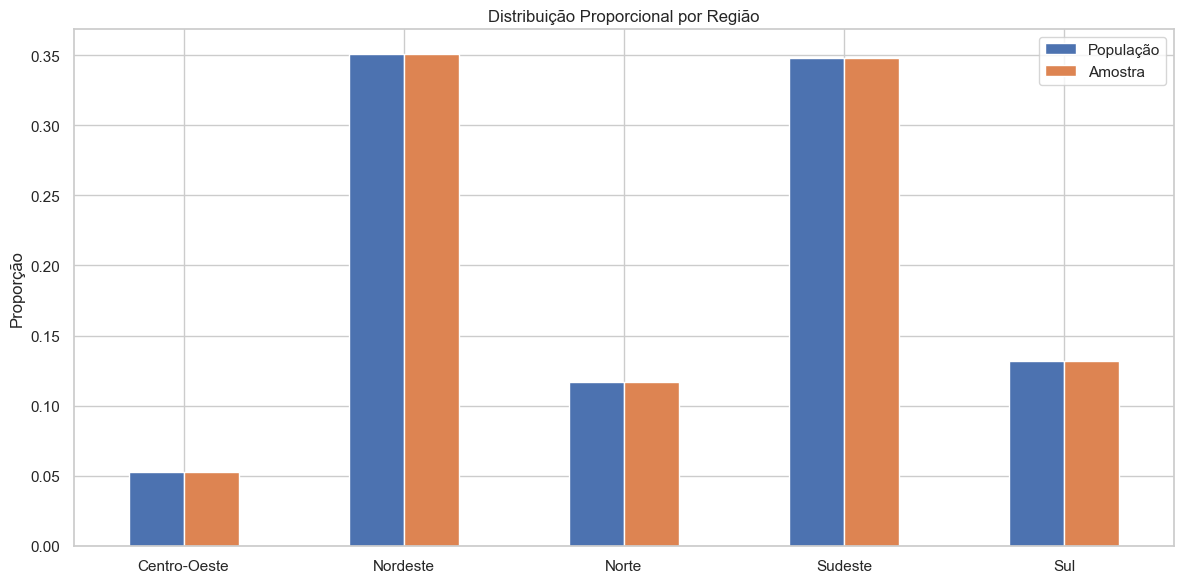

In [5]:
# Frequência relativa na população
pop_freq = df["regiao"].value_counts(normalize=True).sort_index()
amostra_freq = amostra_final["regiao"].value_counts(normalize=True).sort_index()

freq_df = pd.DataFrame({
    "População": pop_freq,
    "Amostra": amostra_freq
})
freq_df.plot(kind="bar", rot=0)
plt.title("Distribuição Proporcional por Região")
plt.ylabel("Proporção")
plt.tight_layout()
plt.show()

## 🧮 Cálculo automático do tamanho da amostra
Utilizamos a fórmula para população finita:
$$
n = \frac{N \cdot Z^2 \cdot p \cdot q}{(N - 1) \cdot e^2 + Z^2 \cdot p \cdot q}
$$
- N: tamanho da população
- Z: valor da distribuição normal para 95% (Z = 1.96)
- p = 0.5, q = 0.5 (máxima variabilidade)
- e = 0.05 (erro amostral)

In [6]:
# Cálculo do tamanho ideal da amostra
from math import ceil

N = len(df)
z = 1.96
p = 0.5
q = 1 - p
e = 0.05

n_calc = (N * (z**2) * p * q) / (((N - 1) * (e**2)) + ((z**2) * p * q))
tamanho_amostra = ceil(n_calc)
print(f"Tamanho ideal da amostra: {tamanho_amostra}")

Tamanho ideal da amostra: 384


## 📊 Estratificação Dupla: Região + Localização

In [7]:
# Definindo os estratos compostos
estratos = df.groupby(['regiao', 'localizacao'])
frequencias = estratos.size() / len(df)
amostra_por_estrato = (frequencias * tamanho_amostra).round().astype(int)
amostra_por_estrato

regiao        localizacao
Centro-Oeste  Rural            3
              Urbana          17
Nordeste      Rural           66
              Urbana          68
Norte         Rural           29
              Urbana          16
Sudeste       Rural           22
              Urbana         111
Sul           Rural            9
              Urbana          41
dtype: int32

In [8]:
# 🔍 Seleção da amostra proporcional por estrato duplo
amostra_final = pd.DataFrame()
for grupo, tamanho in amostra_por_estrato.items():
    subset = df[(df['regiao'] == grupo[0]) & (df['localizacao'] == grupo[1])]
    amostra_estrato = subset.sample(n=tamanho, random_state=42)
    amostra_final = pd.concat([amostra_final, amostra_estrato])
amostra_final.shape

(382, 4)

## 💾 Exportação da Amostra Selecionada

In [9]:
# Exportar para CSV
amostra_final.to_csv("amostra_estratificada.csv", index=False)
print("Amostra exportada com sucesso para 'amostra_estratificada.csv'.")

Amostra exportada com sucesso para 'amostra_estratificada.csv'.


## 📊 Comparação Gráfica: População x Amostra (por Estrato Duplo)

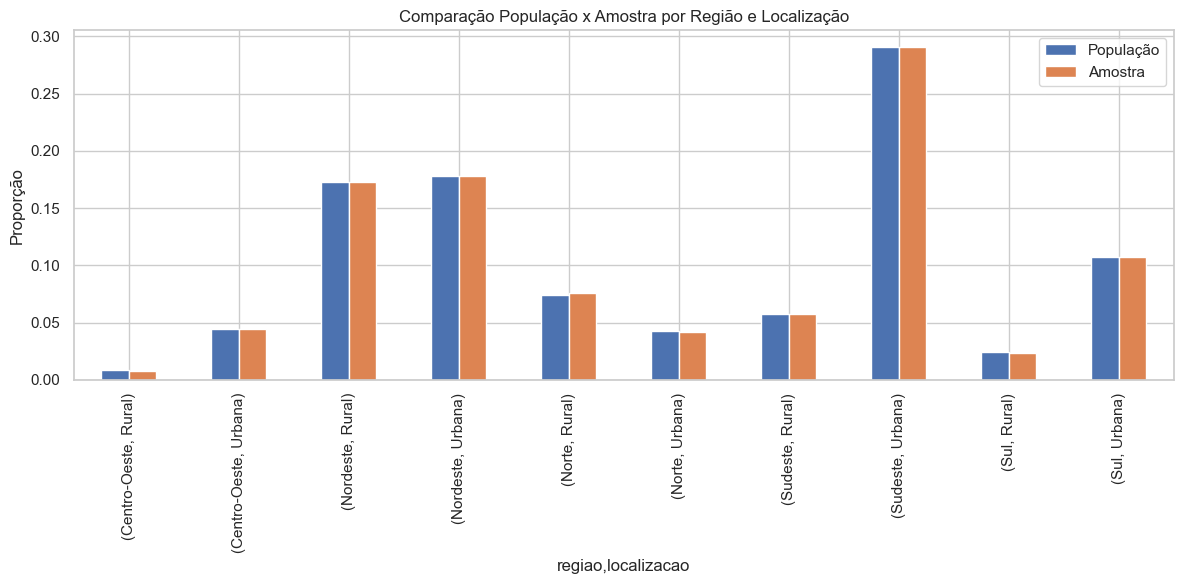

In [10]:
pop_freq = df.groupby(['regiao', 'localizacao']).size().div(len(df))
amostra_freq = amostra_final.groupby(['regiao', 'localizacao']).size().div(len(amostra_final))
comparacao_df = pd.DataFrame({"População": pop_freq, "Amostra": amostra_freq})
comparacao_df.plot(kind="bar", rot=90)
plt.title("Comparação População x Amostra por Região e Localização")
plt.ylabel("Proporção")
plt.tight_layout()
plt.show()